
# Northfield & Co. — EDA, Correlation & Hidden-Factor Analysis, and Time Series Analysis

**Dataset:** `Northfield_Co_Case_Study.xlsx` — daily US e-commerce sales & marketing data,
1 Apr 2024 – 31 Jul 2026 (852 days).

**Business context (from the `Business brief` tab):** Northfield & Co. is a pseudonymised,
mass-market casual-apparel brand (Gap-like: denim, tees, sweats, basics, $20–$90 price points)
selling through US e-commerce (site + app). It runs a **high-frequency promotional model**
(site-wide discounts live ~two-thirds of days), a loyalty-file **email/direct-mail programme**
("UWG" mailings), **in-store promotions** that are believed to lift online demand, and the usual
US retail calendar (holidays, and a Black Friday/Cyber Monday — BFCM — peak). Paid media
(Google, Meta, Microsoft, Criteo, Outbrain, Awin affiliates, occasional influencer content) is
only **~8% of online revenue** — a low-intensity, efficiency-led mix.

**Goal of this notebook**

1. Load and validate all 4 sheets of the workbook.
2. Explore the variables (distributions, seasonality, data quality).
3. Map out **correlations** between marketing spend, promotional/calendar flags and revenue.
4. Go beyond raw correlation to find **hidden / confounding factors** — variables (mostly the
   binary promo & calendar flags, and the day-of-week / seasonal calendar itself) that move
   *both* spend and revenue at the same time, inflating or masking the *direct* relationship
   between a marketing channel and revenue.
5. Run a **time series analysis** (trend/seasonality decomposition, lag structure, event
   studies, rolling correlation) on the revenue series and the channels/factors the correlation
   work flags as important, to show concretely *how* the hidden factors move the numbers.
6. Summarise findings and next steps for the business.

> **Note on causality.** Everything below is *observational*. Where a promo/mailing flag is
> associated with higher revenue, or a spend channel appears to move with revenue, this
> notebook is careful to describe that as an **association observed in the data**, not a proven
> causal effect — the business runs discounts and mailings *because* it expects them to lift
> sales, and flexes paid media up during the same windows, so spend, promotions and revenue are
> all being decided together. This confounding is itself the main "hidden factor" story below.


In [3]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FactorAnalysis

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda v: f'{v:,.2f}')

# --- shared visual style (validated categorical palette, fixed hue order) ---
PALETTE = {
    'blue':    '#2a78d6', 'orange': '#eb6834', 'aqua':   '#1baf7a', 'yellow': '#eda100',
    'magenta': '#e87ba4', 'green':  '#008300', 'violet': '#4a3aa7', 'red':    '#e34948',
}
CAT_ORDER = ['blue', 'orange', 'aqua', 'yellow', 'magenta', 'green', 'violet', 'red']
CAT_HEX = [PALETTE[k] for k in CAT_ORDER]
INK       = '#0b0b0b'
INK_SOFT  = '#52514e'
INK_MUTE  = '#898781'
GRID      = '#e1e0d9'
SURFACE   = '#fcfcfb'
SEQ_BLUE  = ['#cde2fb', '#9ec5f4', '#5598e7', '#2a78d6', '#184f95', '#0d366b']
DIV_CMAP  = sns.diverging_palette(12, 217, s=75, l=50, sep=10, as_cmap=True)  # red<->blue, gray mid

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': GRID, 'axes.labelcolor': INK_SOFT, 'axes.titlecolor': INK,
    'text.color': INK, 'xtick.color': INK_MUTE, 'ytick.color': INK_MUTE,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'axes.grid': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10.5, 'axes.titlesize': 12.5, 'axes.titleweight': 'bold',
    'figure.dpi': 100, 'savefig.dpi': 140,
})

DATA_PATH = 'data/Northfield_Co_Case_Study.xlsx'
print('Setup complete.')


Setup complete.



## 1. Load the full workbook (all 4 sheets)

`Your project` and `Business brief` are context sheets (already summarised above);
`Glossary` documents every field in `Master data`, the actual daily dataset we analyse.


In [4]:

xls = pd.ExcelFile(DATA_PATH)
print('Sheets found:', xls.sheet_names)

project_brief  = pd.read_excel(xls, 'Your project', header=None)
business_brief = pd.read_excel(xls, 'Business brief', header=None)
glossary       = pd.read_excel(xls, 'Glossary').dropna(how='all')
df             = pd.read_excel(xls, 'Master data')

df = df.sort_values('Date').reset_index(drop=True)
print(f"Master data: {df.shape[0]} rows x {df.shape[1]} columns, "
      f"{df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Northfield_Co_Case_Study.xlsx'

In [ ]:

# Glossary — one row per field, straight from the workbook (used as our field dictionary)
glossary


,Glossary — Master data fields,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,"One row per column in the Master data tab, in ...",NaN,NaN,NaN
2,Field,Category,Unit,Definition
3,Date,Dimension,Date,Calendar day (US Eastern) to which all metrics...
4,UWG_Mailing,Control (binary),0 / 1,1 on days a customer mailing coded 'UWG' (emai...
5,BFCM_Promo_Effect,Control (binary),0 / 1,1 during the Black Friday / Cyber Monday promo...
6,holiday_list,Control (binary),0 / 1,1 on US public and retail holidays (e.g. Easte...
7,Offline_Promo,Control (binary),0 / 1,1 on days an in-store promotion was running in...
8,Promotion_Discount,Control (binary),0 / 1,1 on days a site-wide online discount or promo...
9,Total_Revenue,KPI (primary),USD,Daily net online revenue (site + app) after di...
10,Revenue_New_Customer,KPI (secondary),USD,Portion of Total_Revenue from customers placin...



## 2. Data quality & integrity checks

Before any analysis, we check: date continuity/duplicates, missing values, roll-up
consistency (`spend_Google` = sum of its 5 components; `spend_Meta` = sum of its 3), sign
sanity (no negative spend/revenue), and flag down obvious outliers so we know *why* they are
large rather than treating them as data errors.


In [ ]:

checks = {}

# date continuity
full_range = pd.date_range(df['Date'].min(), df['Date'].max(), freq='D')
checks['missing calendar days']  = len(full_range.difference(df['Date']))
checks['duplicated dates']       = int(df['Date'].duplicated().sum())
checks['any missing values']     = int(df.isna().sum().sum())
checks['any negative values']    = int((df.select_dtypes('number') < 0).sum().sum())

google_components = ['spend_Google_Branded','spend_Google_Non_Branded','spend_Google_PMAX',
                      'spend_Google_Demand_Gen','spend_Google_Others']
meta_components   = ['spend_Meta_ASC','spend_Meta_Retargeting','spend_Meta_Prospecting']
checks['max |spend_Google - sum(components)|'] = round(
    (df['spend_Google'] - df[google_components].sum(axis=1)).abs().max(), 2)
checks['max |spend_Meta - sum(components)|']   = round(
    (df['spend_Meta']   - df[meta_components].sum(axis=1)).abs().max(), 2)

for k, v in checks.items():
    print(f'{k:45s}: {v}')

print()
print('Verdict: no missing days, no duplicate dates, no missing/negative values.')
print('Google roll-up matches components almost exactly; Meta roll-up differs by at most a')
print('few dollars on any given day (~$0.93 average) — consistent with the brief\'s note that')
print('platform roll-ups carry small rounding vs. the reported components. Not a data error.')


missing calendar days                        : 0
duplicated dates                             : 0
any missing values                           : 0
any negative values                          : 0
max |spend_Google - sum(components)|         : 0.01
max |spend_Meta - sum(components)|           : 17.11

Verdict: no missing days, no duplicate dates, no missing/negative values.
Google roll-up matches components almost exactly; Meta roll-up differs by at most a
few dollars on any given day (~$0.93 average) — consistent with the brief's note that
platform roll-ups carry small rounding vs. the reported components. Not a data error.


In [ ]:

# Outlier scan on the primary KPI — Tukey 3x-IQR fence, then check WHAT explains them
q1, q3 = df['Total_Revenue'].quantile([.25, .75])
fence = q3 + 3 * (q3 - q1)
outliers = df.loc[df['Total_Revenue'] > fence,
                   ['Date','Total_Revenue','UWG_Mailing','BFCM_Promo_Effect',
                    'Promotion_Discount','Offline_Promo','holiday_list']].copy()
outliers['dow'] = outliers['Date'].dt.day_name()

print(f"{len(outliers)} of {len(df)} days sit above the 3xIQR fence (${fence:,.0f}).")
print(f"Of these, {outliers['UWG_Mailing'].sum()} coincide with a UWG mailing and "
      f"{outliers['BFCM_Promo_Effect'].sum()} with the BFCM window — i.e. essentially all of "
      f"the revenue outliers are explained by known promotional/calendar events, not bad data.")
outliers.sort_values('Total_Revenue', ascending=False).head(12)


25 of 852 days sit above the 3xIQR fence ($144,874).
Of these, 19 coincide with a UWG mailing and 8 with the BFCM window — i.e. essentially all of the revenue outliers are explained by known promotional/calendar events, not bad data.


,Date,Total_Revenue,UWG_Mailing,BFCM_Promo_Effect,Promotion_Discount,Offline_Promo,holiday_list,dow
606,2025-11-28,"289,548.00",1,1,1,0,0,Friday
608,2025-11-30,"287,538.00",1,1,1,0,0,Sunday
601,2025-11-23,"265,947.00",1,1,1,0,0,Sunday
244,2024-12-01,"262,356.00",1,1,1,0,0,Sunday
223,2024-11-10,"249,704.00",1,0,1,0,0,Sunday
242,2024-11-29,"226,062.00",1,1,1,0,0,Friday
440,2025-06-15,"225,265.00",1,0,1,1,1,Sunday
6,2024-04-07,"217,347.00",1,0,1,1,0,Sunday
587,2025-11-09,"214,958.00",1,0,1,1,0,Sunday
447,2025-06-22,"202,166.00",1,0,1,1,0,Sunday



## 3. Univariate exploration

Field dictionary recap:

- **KPIs**: `Total_Revenue` (daily net online revenue), `Revenue_New_Customer` (the acquisition
  slice of it).
- **Binary control/event flags**: `Promotion_Discount`, `Offline_Promo`, `UWG_Mailing`,
  `BFCM_Promo_Effect`, `holiday_list` — these describe *when* something promotional or seasonal
  was happening, and are the prime suspects for "hidden factors" below.
- **Paid media spend** (13 lines + 2 roll-ups): Google (5 sub-channels + roll-up), Meta (3
  sub-channels + roll-up), Microsoft, Criteo, Outbrain, Awin (affiliate, commission-based),
  influencer (sporadic, ~2% of days active).


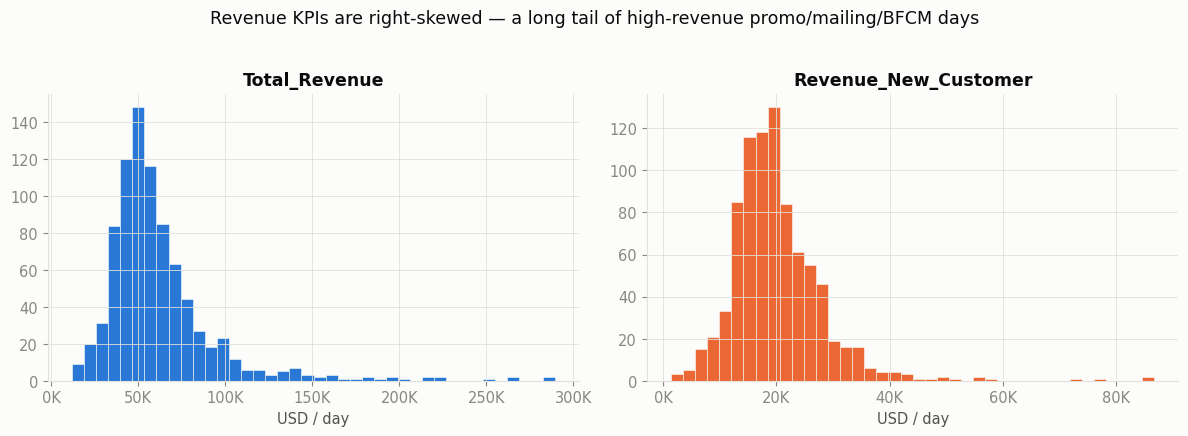

                      count      mean       std       min       25%       50%       75%        max
Total_Revenue        852.00 62,091.13 32,998.69 11,848.00 43,792.88 54,426.50 69,063.25 289,548.00
Revenue_New_Customer 852.00 20,163.69  8,408.15  1,407.55 15,185.60 18,923.40 23,693.78  86,734.11


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, col, hue in zip(axes, ['Total_Revenue', 'Revenue_New_Customer'], [CAT_HEX[0], CAT_HEX[1]]):
    ax.hist(df[col], bins=40, color=hue, edgecolor=SURFACE, linewidth=0.4)
    ax.set_title(col)
    ax.set_xlabel('USD / day')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
fig.suptitle('Revenue KPIs are right-skewed — a long tail of high-revenue promo/mailing/BFCM days', y=1.03)
plt.tight_layout(); plt.show()

print(df[['Total_Revenue','Revenue_New_Customer']].describe().T)


In [ ]:

spend_cols = ['influencer_spend','Awin_spend','microsoft_spend','criteo_spend','cost_outbrain',
              'spend_Google_Branded','spend_Google_Non_Branded','spend_Google_PMAX',
              'spend_Google_Demand_Gen','spend_Google_Others',
              'spend_Meta_ASC','spend_Meta_Retargeting','spend_Meta_Prospecting']
flag_cols  = ['UWG_Mailing','BFCM_Promo_Effect','holiday_list','Offline_Promo','Promotion_Discount']
kpi_cols   = ['Total_Revenue','Revenue_New_Customer']

summary = df[spend_cols].agg(['mean','median','std','max']).T
summary['pct_days_zero'] = (df[spend_cols] == 0).mean() * 100
summary.sort_values('mean', ascending=False).round(1)


,mean,median,std,max,pct_days_zero
spend_Google_PMAX,"1,257.20","1,233.20",594.10,"5,779.20",0.60
spend_Google_Branded,"1,227.90","1,182.00",399.40,"3,710.30",0.60
spend_Meta_ASC,835.90,777.60,426.40,"4,948.20",0.00
spend_Meta_Prospecting,377.80,357.20,178.90,"1,615.90",0.40
Awin_spend,287.30,240.20,199.00,"1,642.10",0.00
spend_Google_Non_Branded,240.50,179.90,164.00,935.70,0.60
spend_Meta_Retargeting,216.50,200.60,113.20,"1,022.00",0.00
criteo_spend,145.40,135.10,74.40,"1,006.40",0.10
cost_outbrain,137.10,109.50,114.20,757.40,0.00
microsoft_spend,118.80,116.20,35.80,313.40,0.00


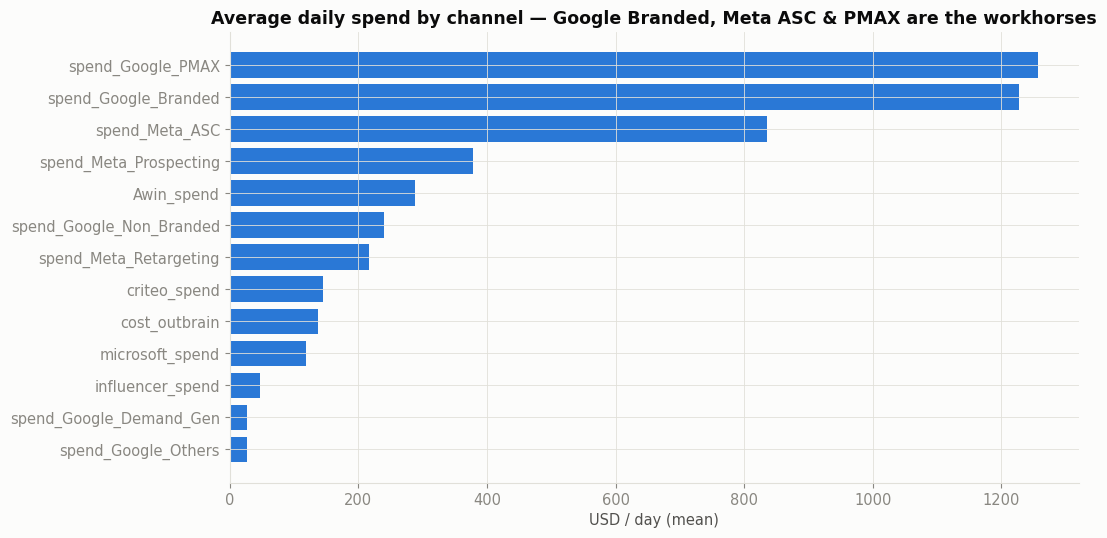

Media spend is ~8% of revenue as the brief states: total daily media ≈ $4,946 vs. Total_Revenue ≈ $62,091.


In [ ]:

fig, ax = plt.subplots(figsize=(11, 5.5))
means = df[spend_cols].mean().sort_values(ascending=False)
ax.barh(means.index[::-1], means.values[::-1], color=CAT_HEX[0])
ax.set_title('Average daily spend by channel — Google Branded, Meta ASC & PMAX are the workhorses')
ax.set_xlabel('USD / day (mean)')
plt.tight_layout(); plt.show()

print(f"Media spend is ~8% of revenue as the brief states: "
      f"total daily media ≈ ${df[['spend_Google','spend_Meta','microsoft_spend','criteo_spend','cost_outbrain','Awin_spend','influencer_spend']].sum(axis=1).mean():,.0f} "
      f"vs. Total_Revenue ≈ ${df['Total_Revenue'].mean():,.0f}.")


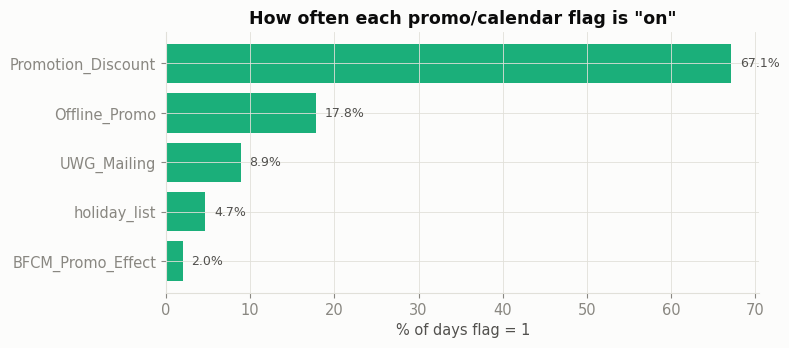

In [ ]:

# Flags — how common is each event?
flag_rate = (df[flag_cols].mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(flag_rate.index[::-1], flag_rate.values[::-1], color=CAT_HEX[2])
ax.set_xlabel('% of days flag = 1')
ax.set_title('How often each promo/calendar flag is "on"')
for i, v in enumerate(flag_rate.values[::-1]):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', color=INK_SOFT, fontsize=9)
plt.tight_layout(); plt.show()



## 4. Calendar seasonality — day-of-week is the single biggest pattern in the data

This section matters for what follows: **day-of-week is not a column in the dataset**, but it
turns out to be one of the strongest drivers of revenue, and it is *also* correlated with when
mailings are sent and when media spend is flexed up. That makes it a textbook hidden/confounding
factor — we derive it from `Date` and carry it through the rest of the notebook.


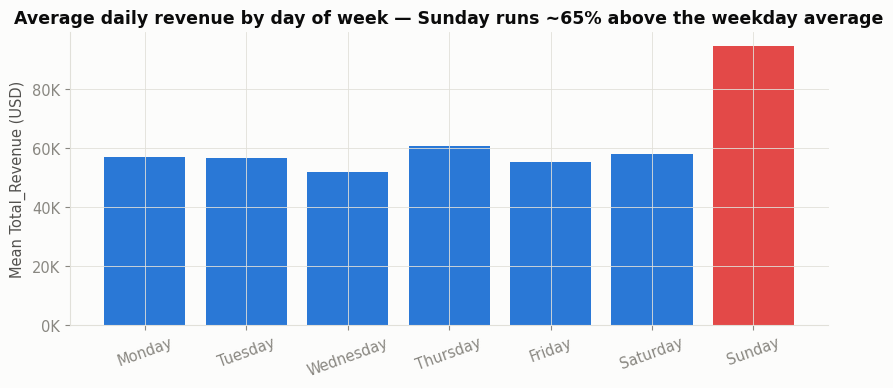

Sunday mean revenue: $94,816  vs.  weekday(Mon-Sat) mean: $56,676 (+67%).


In [ ]:

df['dow']  = df['Date'].dt.day_name()
df['dow_n']= df['Date'].dt.dayofweek       # 0=Mon .. 6=Sun
df['month']= df['Date'].dt.month
df['t']    = np.arange(len(df))            # linear trend index, for later regressions

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev   = df.groupby('dow')['Total_Revenue'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(8.5, 4))
colors = [CAT_HEX[7] if d == 'Sunday' else CAT_HEX[0] for d in dow_order]
ax.bar(dow_order, dow_rev.values, color=colors)
ax.set_title('Average daily revenue by day of week — Sunday runs ~65% above the weekday average')
ax.set_ylabel('Mean Total_Revenue (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

weekday_avg = dow_rev.drop('Sunday').mean()
print(f"Sunday mean revenue: ${dow_rev['Sunday']:,.0f}  vs.  weekday(Mon-Sat) mean: ${weekday_avg:,.0f} "
      f"(+{dow_rev['Sunday']/weekday_avg-1:.0%}).")


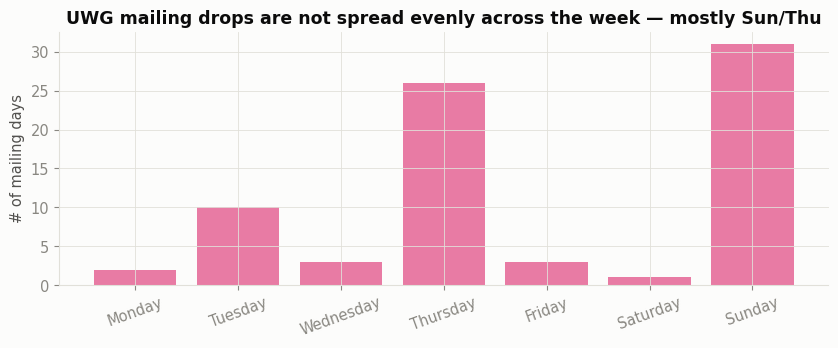

dow
Monday        2
Tuesday      10
Wednesday     3
Thursday     26
Friday        3
Saturday      1
Sunday       31
Name: count, dtype: int64

57 of 76 mailings (75%) land on a Sunday or Thursday — so part of the mailing's apparent revenue effect is really Sunday's own baseline lift.


In [ ]:

# Where do the promo/mailing events themselves land in the week?
mail_dow = df.loc[df['UWG_Mailing']==1, 'dow'].value_counts().reindex(dow_order).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(8.5, 3.6))
ax.bar(dow_order, mail_dow.values, color=CAT_HEX[4])
ax.set_title('UWG mailing drops are not spread evenly across the week — mostly Sun/Thu')
ax.set_ylabel('# of mailing days')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
print(mail_dow)
print(f"\n{mail_dow['Sunday']+mail_dow['Thursday']} of {mail_dow.sum()} mailings "
      f"({(mail_dow['Sunday']+mail_dow['Thursday'])/mail_dow.sum():.0%}) land on a Sunday or Thursday — "
      f"so part of the mailing's apparent revenue effect is really Sunday's own baseline lift.")



## 5. Correlation analysis

We compute both **Pearson** (linear) and **Spearman** (monotonic, rank-based — more robust to
the heavy right skew in spend/revenue) correlations across every numeric field. Roll-up columns
(`spend_Google`, `spend_Meta`) are excluded from the heatmap since they are definitionally the
sum of their own components (kept in later derived-metric steps only).


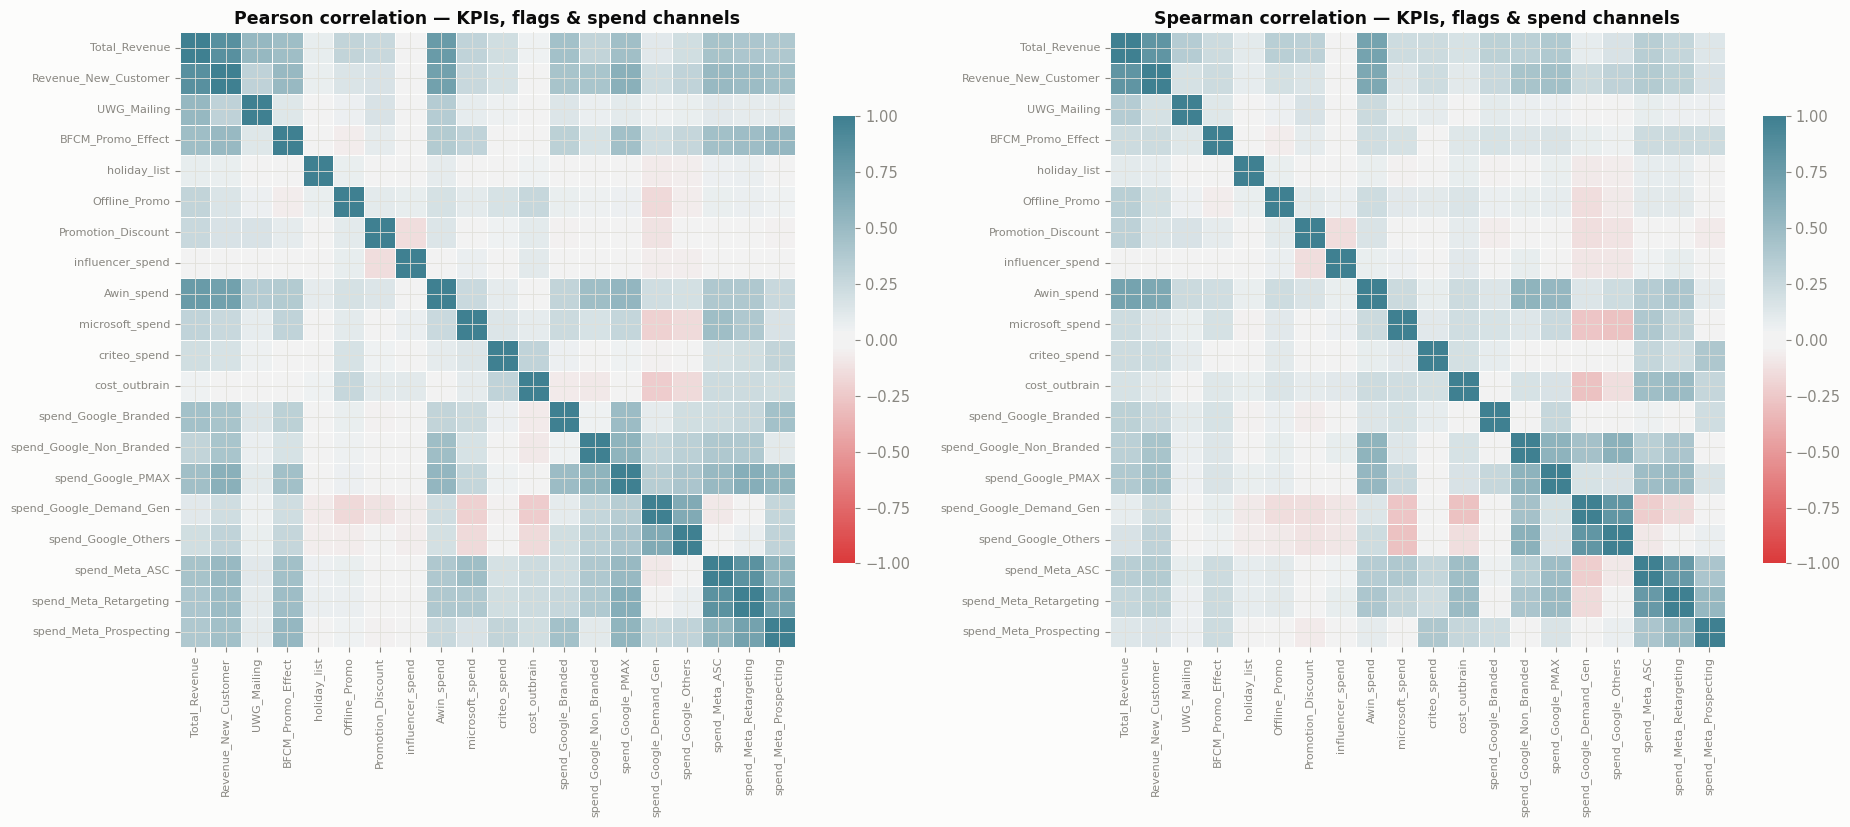

In [ ]:

corr_cols = kpi_cols + flag_cols + spend_cols
pearson_corr  = df[corr_cols].corr(method='pearson')
spearman_corr = df[corr_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(19, 8))
for ax, mat, name in zip(axes, [pearson_corr, spearman_corr], ['Pearson', 'Spearman']):
    sns.heatmap(mat, cmap=DIV_CMAP, vmin=-1, vmax=1, center=0, square=True,
                linewidths=0.4, linecolor=SURFACE, cbar_kws={'shrink':0.7}, ax=ax)
    ax.set_title(f'{name} correlation — KPIs, flags & spend channels')
    ax.tick_params(labelsize=8)
plt.tight_layout(); plt.show()


In [ ]:

raw_corr = pearson_corr['Total_Revenue'].drop(['Total_Revenue']).sort_values(ascending=False)
print('Correlation of every variable with Total_Revenue (Pearson), descending:\n')
print(raw_corr.to_string())


Correlation of every variable with Total_Revenue (Pearson), descending:

Revenue_New_Customer        0.86
Awin_spend                  0.76
UWG_Mailing                 0.52
BFCM_Promo_Effect           0.47
spend_Google_PMAX           0.47
spend_Google_Branded        0.45
spend_Meta_ASC              0.44
spend_Meta_Retargeting      0.41
spend_Meta_Prospecting      0.38
microsoft_spend             0.29
spend_Google_Non_Branded    0.29
Offline_Promo               0.28
Promotion_Discount          0.26
criteo_spend                0.20
spend_Google_Others         0.20
spend_Google_Demand_Gen     0.12
holiday_list                0.08
cost_outbrain               0.04
influencer_spend           -0.01



**Reading the raw numbers:**

- `Revenue_New_Customer` is almost mechanically tied to `Total_Revenue` (it's a *component* of
  it) — expected, not informative about media.
- `Awin_spend` (affiliate) has the **highest correlation of any spend channel with revenue
  (~0.76)** — but Awin is paid on **commission**, i.e. affiliate spend is partly a *consequence*
  of sales, not only a cause of them. A high raw correlation here should not be read as "affiliate
  spend drives revenue" without checking that mechanical, reverse-causal link.
- The promo/calendar **flags** (`UWG_Mailing` 0.52, `BFCM_Promo_Effect` 0.47, `Offline_Promo`
  0.28, `Promotion_Discount` 0.26) correlate with revenue *on their own*, without any spend
  attached — a first sign that non-media, calendar-driven demand is doing a lot of the work.
- Google PMAX, Google Branded and the three Meta lines sit in the 0.38–0.47 range — the next
  section checks how much of that survives once we control for the flags and the calendar.



## 6. Hidden factors, part 1 — promo/calendar flags as confounders

**The idea.** A raw correlation between spend on channel *X* and `Total_Revenue` can be large
even if X has *no* direct effect on revenue, as long as some third variable *Z* (a promo, a
mailing, a day of week, the BFCM window, the growth trend) moves **both** X and revenue at the
same time. Northfield's playbook makes this almost guaranteed: the team **flexes media spend up
during promotions and BFCM**, and revenue independently rises on those same days because of the
discount/mailing/seasonal effect itself — not because of the extra ad spend.

**Method.** For each spend channel and for `Total_Revenue`, we regress the variable on the known
"hidden factor" controls — day-of-week dummies, the 5 promo/calendar flags, and a linear time
trend — and keep the **residuals** (the part of each series *not* explained by the calendar).
Correlating the residuals is a **partial correlation**: the relationship between spend and
revenue *after* removing everything the calendar already explains. Comparing it to the raw
correlation shows exactly how much of the raw number was calendar-driven confounding.


In [ ]:

dow_dummies = pd.get_dummies(df['dow_n'], prefix='dow', drop_first=True).astype(float)
controls = sm.add_constant(pd.concat([dow_dummies, df[flag_cols], df[['t']]], axis=1).astype(float))

def residualize(y):
    return sm.OLS(y.astype(float), controls).fit().resid

resid_rev   = residualize(df['Total_Revenue'])
resid_spend = {c: residualize(df[c]) for c in spend_cols}

rows = []
for c in spend_cols:
    raw = df[c].corr(df['Total_Revenue'])
    partial = np.corrcoef(resid_rev, resid_spend[c])[0, 1]
    rows.append((c, raw, partial, raw - partial))

confound_tbl = pd.DataFrame(rows, columns=['channel', 'raw_corr', 'partial_corr_ex_calendar', 'confounding_gap'])
confound_tbl = confound_tbl.sort_values('raw_corr', ascending=False).reset_index(drop=True)
confound_tbl['pct_of_raw_explained_by_calendar'] = (confound_tbl['confounding_gap'] / confound_tbl['raw_corr']).clip(-2, 2)
confound_tbl.round(3)


,channel,raw_corr,partial_corr_ex_calendar,confounding_gap,pct_of_raw_explained_by_calendar
0,Awin_spend,0.76,0.64,0.12,0.16
1,spend_Google_PMAX,0.47,0.35,0.12,0.26
2,spend_Google_Branded,0.45,0.33,0.12,0.26
3,spend_Meta_ASC,0.44,0.29,0.14,0.33
4,spend_Meta_Retargeting,0.41,0.24,0.17,0.42
5,spend_Meta_Prospecting,0.38,0.17,0.21,0.56
6,microsoft_spend,0.29,0.26,0.04,0.12
7,spend_Google_Non_Branded,0.29,0.29,-0.00,-0.01
8,criteo_spend,0.20,0.17,0.03,0.15
9,spend_Google_Others,0.20,0.11,0.10,0.48


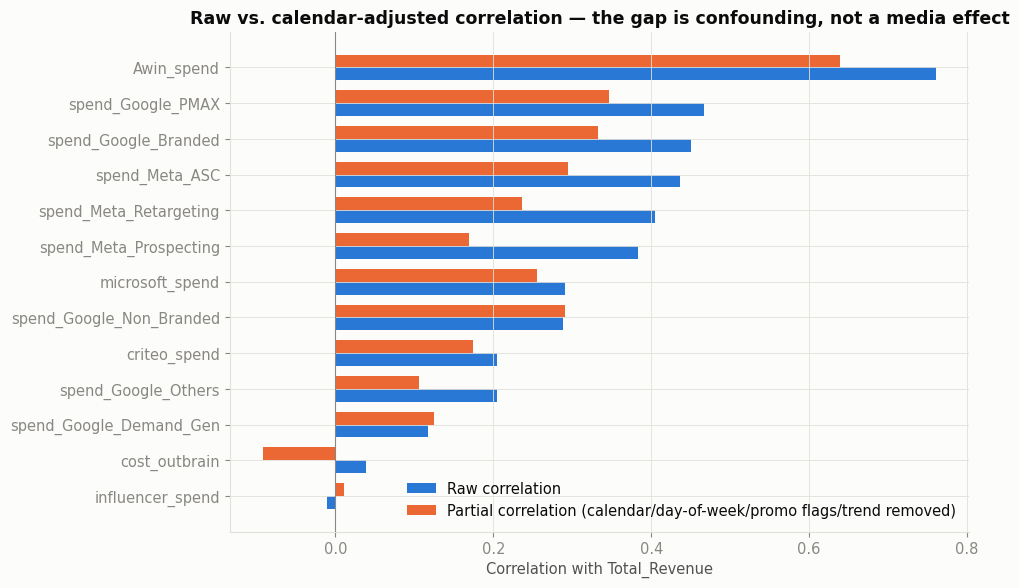

Channels where the calendar explains the largest share of the raw correlation:
               channel  raw_corr  partial_corr_ex_calendar  confounding_gap
spend_Meta_Prospecting      0.38                      0.17             0.21
spend_Meta_Retargeting      0.41                      0.24             0.17
        spend_Meta_ASC      0.44                      0.29             0.14


In [ ]:

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(confound_tbl))
ax.barh(y + 0.18, confound_tbl['raw_corr'], height=0.36, color=CAT_HEX[0], label='Raw correlation')
ax.barh(y - 0.18, confound_tbl['partial_corr_ex_calendar'], height=0.36, color=CAT_HEX[1],
        label='Partial correlation (calendar/day-of-week/promo flags/trend removed)')
ax.set_yticks(y); ax.set_yticklabels(confound_tbl['channel'])
ax.axvline(0, color=INK_MUTE, linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel('Correlation with Total_Revenue')
ax.set_title('Raw vs. calendar-adjusted correlation — the gap is confounding, not a media effect')
ax.legend(loc='lower right', frameon=False)
plt.tight_layout(); plt.show()

biggest = confound_tbl.iloc[(confound_tbl['confounding_gap']).abs().sort_values(ascending=False).index[:3]]
print('Channels where the calendar explains the largest share of the raw correlation:')
print(biggest[['channel','raw_corr','partial_corr_ex_calendar','confounding_gap']].to_string(index=False))



**Reading it:** every channel's correlation with revenue shrinks once day-of-week, the five
promo/calendar flags and the growth trend are accounted for — none flips to strongly negative,
so none of this is "media hurts revenue", but the *size* of the apparent relationship is
substantially inflated by shared timing. `spend_Meta_Prospecting` shrinks the most in relative
terms (0.38 → 0.17, a ~55% reduction) — most of its raw correlation with revenue is calendar
timing, not a direct link. `Awin_spend` stays the strongest channel even after adjustment
(0.76 → 0.64) — still partly explainable by its commission-based, revenue-linked payout
structure rather than a pure "spend causes revenue" story.



## 7. Hidden factors, part 2 — a latent "media-intensity" factor behind the spend channels

The channels aren't flexed independently: on a day the team pushes Meta ASC harder, they
typically push Google PMAX and Meta Retargeting harder too. We use PCA on the (standardised)
spend channels to see whether a **single hidden factor** — a general "push the media budget
today" behaviour — explains a meaningful share of the co-movement, and then check what drives
*that* factor.


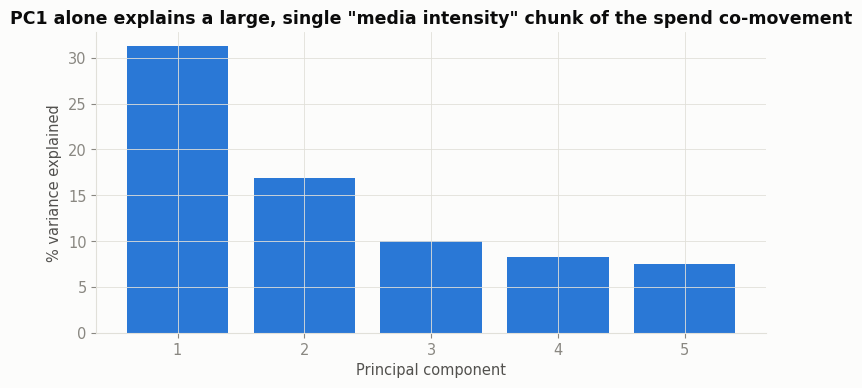

PC1 explains 31.3% of total variance across the 13 spend channels.


,PC1_media_intensity,PC2
spend_Google_PMAX,0.42,0.16
spend_Meta_Retargeting,0.41,-0.22
spend_Meta_ASC,0.39,-0.26
spend_Meta_Prospecting,0.37,-0.04
Awin_spend,0.31,0.09
spend_Google_Non_Branded,0.29,0.19
spend_Google_Branded,0.25,0.06
microsoft_spend,0.22,-0.31
spend_Google_Others,0.18,0.48
spend_Google_Demand_Gen,0.14,0.52


In [ ]:

X = StandardScaler().fit_transform(df[spend_cols])
pca = PCA(n_components=5).fit(X)
scores = pca.transform(X)
df['media_intensity_pc1'] = scores[:, 0]

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(range(1, 6), pca.explained_variance_ratio_ * 100, color=CAT_HEX[0])
ax.set_xticks(range(1, 6)); ax.set_xlabel('Principal component'); ax.set_ylabel('% variance explained')
ax.set_title('PC1 alone explains a large, single "media intensity" chunk of the spend co-movement')
plt.tight_layout(); plt.show()
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%} of total variance across the 13 spend channels.")

loadings = pd.DataFrame(pca.components_[:2].T, index=spend_cols, columns=['PC1_media_intensity', 'PC2'])
loadings.sort_values('PC1_media_intensity', ascending=False).round(2)


What is PC1 correlated with?
  corr(PC1, Total_Revenue       ) = +0.623
  corr(PC1, Promotion_Discount  ) = +0.016
  corr(PC1, BFCM_Promo_Effect   ) = +0.575
  corr(PC1, UWG_Mailing         ) = +0.190
  corr(PC1, linear trend (t)    ) = +0.137


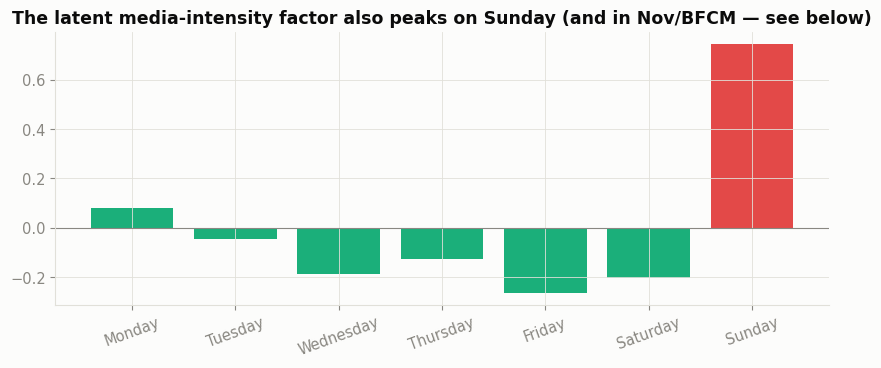

In [ ]:

print('What is PC1 correlated with?')
for label, series in [('Total_Revenue', df['Total_Revenue']),
                       ('Promotion_Discount', df['Promotion_Discount']),
                       ('BFCM_Promo_Effect', df['BFCM_Promo_Effect']),
                       ('UWG_Mailing', df['UWG_Mailing']),
                       ('linear trend (t)', df['t'])]:
    print(f'  corr(PC1, {label:20s}) = {np.corrcoef(df["media_intensity_pc1"], series)[0,1]:+.3f}')

pc1_dow = df.groupby('dow')['media_intensity_pc1'].mean().reindex(dow_order)
fig, ax = plt.subplots(figsize=(8.5, 3.8))
colors = [CAT_HEX[7] if d=='Sunday' else CAT_HEX[2] for d in dow_order]
ax.bar(dow_order, pc1_dow.values, color=colors)
ax.axhline(0, color=INK_MUTE, linewidth=0.8)
ax.set_title('The latent media-intensity factor also peaks on Sunday (and in Nov/BFCM — see below)')
plt.xticks(rotation=20)
plt.tight_layout(); plt.show()



**The hidden factor, unmasked:** PC1 correlates strongly with revenue (~0.62) but only weakly
with the `Promotion_Discount` flag directly (~0.02) — the binary flag alone doesn't capture it.
What PC1 really tracks is **Sunday** and **November/BFCM**: the same calendar rhythm that drives
`Total_Revenue` on its own also happens to be when the team simultaneously turns up PMAX, Meta
ASC/Retargeting/Prospecting and Google Non-Branded together. In other words, *day-of-week and
the November peak are the hidden factor sitting behind "media spend correlates with revenue"* —
a coordinated calendar-driven budget rhythm, not (necessarily) a causal media lift.



## 8. Hidden factors, part 3 — does the spend↔revenue picture change once we split by promo day?

A quick visual gut-check: plot a representative channel against revenue, colouring points by
`Promotion_Discount`. If the *within-group* slope looks different from the *pooled* slope, that's
a visible Simpson's-paradox-style symptom of confounding.


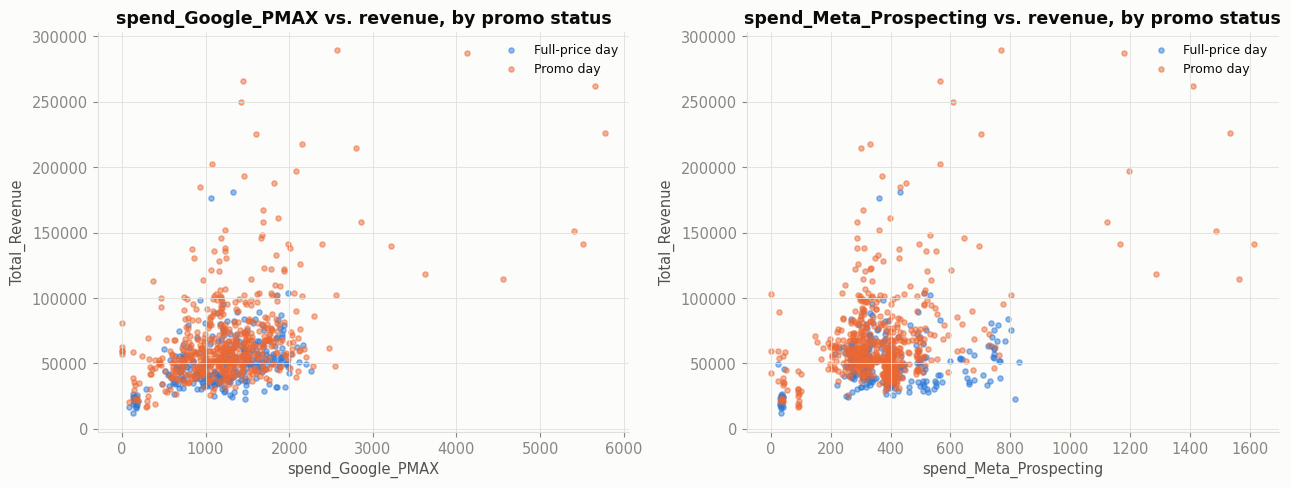

Promo days sit systematically higher on the revenue axis at every spend level — the promo
flag shifts the whole cluster up rather than just changing how steep the spend/revenue
relationship is. That is the confounding signature: promo status is a "level shifter" that
a same-day, unlagged spend/revenue correlation cannot distinguish from a genuine media effect.


In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ch in zip(axes, ['spend_Google_PMAX', 'spend_Meta_Prospecting']):
    for flag_val, color, label in [(0, CAT_HEX[0], 'Full-price day'), (1, CAT_HEX[1], 'Promo day')]:
        sub = df[df['Promotion_Discount'] == flag_val]
        ax.scatter(sub[ch], sub['Total_Revenue'], s=14, alpha=0.5, color=color, label=label)
    ax.set_xlabel(ch); ax.set_ylabel('Total_Revenue')
    ax.set_title(f'{ch} vs. revenue, by promo status')
    ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print('Promo days sit systematically higher on the revenue axis at every spend level — the promo')
print('flag shifts the whole cluster up rather than just changing how steep the spend/revenue')
print('relationship is. That is the confounding signature: promo status is a "level shifter" that')
print('a same-day, unlagged spend/revenue correlation cannot distinguish from a genuine media effect.')



## 9. Lag structure — is there a delayed ("adstock") relationship, or is it all same-day?

If spend on channel X truly *drove* future revenue, we would expect the spend↔revenue
correlation to hold up (or even peak) at a lag of 1–3 days as the campaign's effect plays out.
If instead the correlation is highest at **lag 0** and decays monotonically, that is more
consistent with spend and revenue both reacting to the *same* same-day calendar event — i.e.
confounding again, not a lasting media effect.


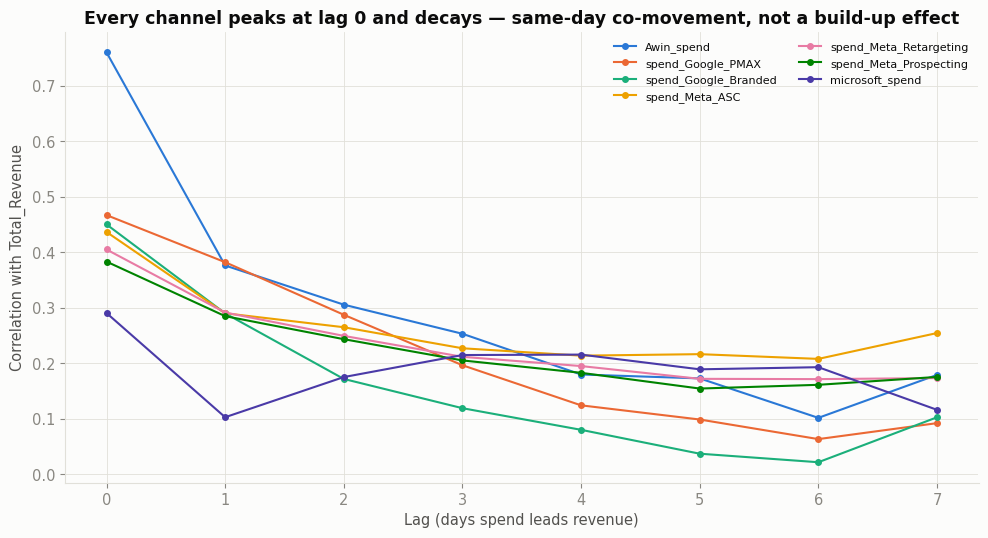

Lag at which correlation peaks, by channel (0 = same day):
Awin_spend                0
spend_Google_PMAX         0
spend_Google_Branded      0
spend_Meta_ASC            0
spend_Meta_Retargeting    0
spend_Meta_Prospecting    0
microsoft_spend           0


In [ ]:

lag_channels = ['Awin_spend','spend_Google_PMAX','spend_Google_Branded','spend_Meta_ASC',
                'spend_Meta_Retargeting','spend_Meta_Prospecting','microsoft_spend']
max_lag = 7
lag_tbl = pd.DataFrame({
    ch: [df[ch].shift(lag).corr(df['Total_Revenue']) for lag in range(max_lag + 1)]
    for ch in lag_channels
}, index=range(max_lag + 1))

fig, ax = plt.subplots(figsize=(10, 5.5))
for i, ch in enumerate(lag_channels):
    ax.plot(lag_tbl.index, lag_tbl[ch], marker='o', ms=4, color=CAT_HEX[i % len(CAT_HEX)], label=ch)
ax.set_xlabel('Lag (days spend leads revenue)'); ax.set_ylabel('Correlation with Total_Revenue')
ax.set_title('Every channel peaks at lag 0 and decays — same-day co-movement, not a build-up effect')
ax.legend(fontsize=8, ncol=2, frameon=False)
plt.tight_layout(); plt.show()

peak_lags = lag_tbl.idxmax()
print('Lag at which correlation peaks, by channel (0 = same day):')
print(peak_lags.to_string())



## 10. Time series decomposition of `Total_Revenue`

We decompose the daily revenue series (STL, weekly period = 7) into **trend**, **weekly
seasonal**, and **residual** components. The trend shows the underlying 2+ year growth path with
the November spikes and December troughs; the seasonal component isolates the Sunday effect
identified above as a clean, repeating weekly wave.


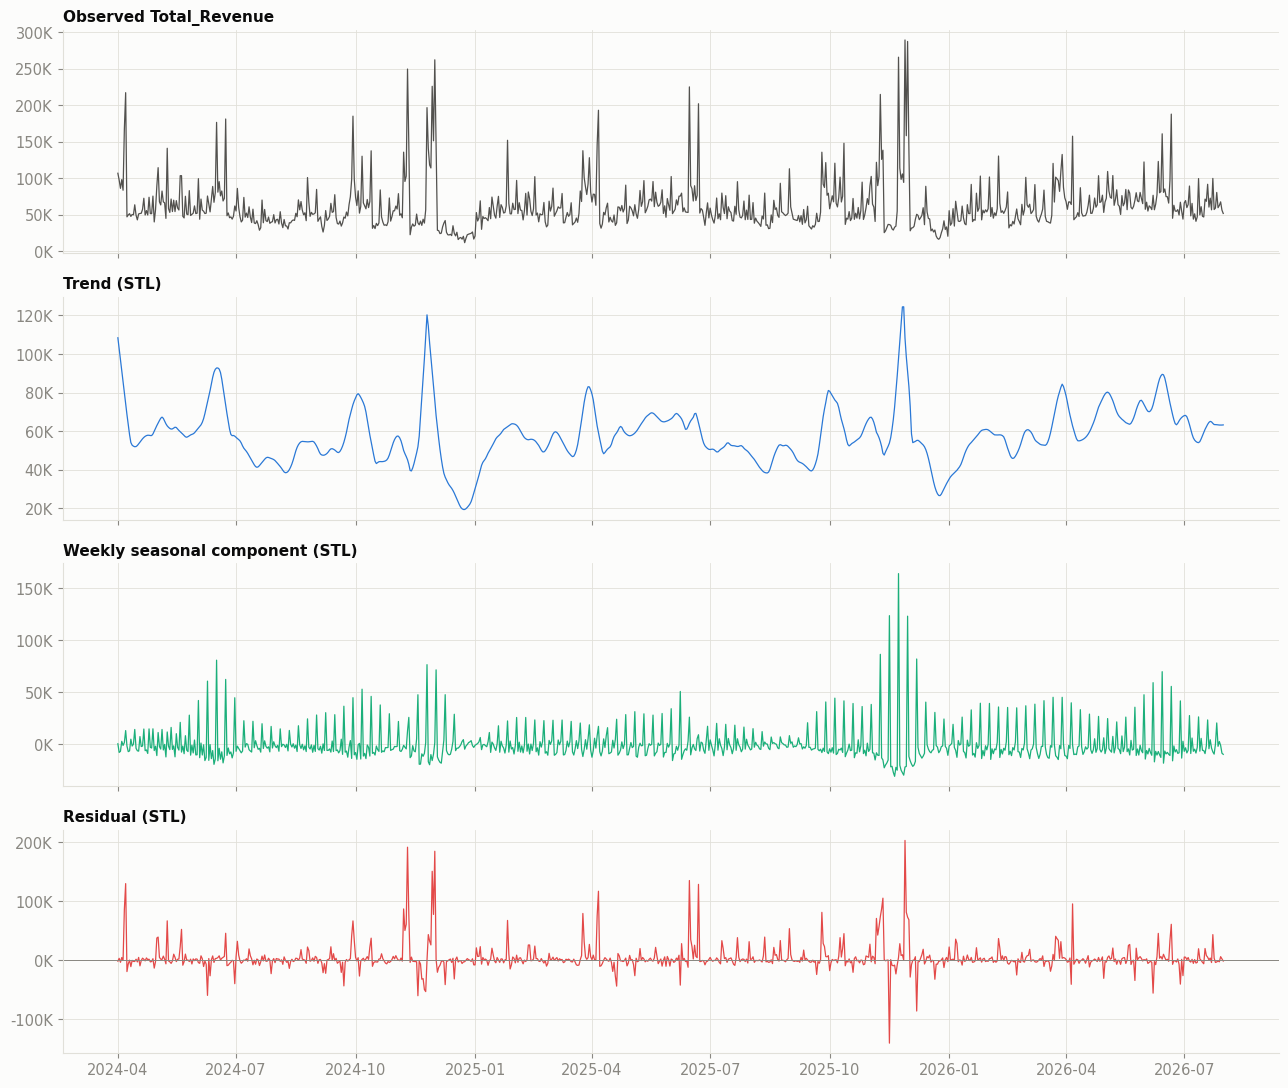

In [ ]:

ts = df.set_index('Date')['Total_Revenue']
stl = STL(ts, period=7, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 11), sharex=True)
for ax, series, title, color in zip(
    axes, [ts, stl.trend, stl.seasonal, stl.resid],
    ['Observed Total_Revenue', 'Trend (STL)', 'Weekly seasonal component (STL)', 'Residual (STL)'],
    [INK_SOFT, CAT_HEX[0], CAT_HEX[2], CAT_HEX[7]]
):
    ax.plot(series.index, series.values, color=color, linewidth=0.9)
    ax.set_title(title, loc='left', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[-1].axhline(0, color=INK_MUTE, linewidth=0.7)
plt.tight_layout(); plt.show()


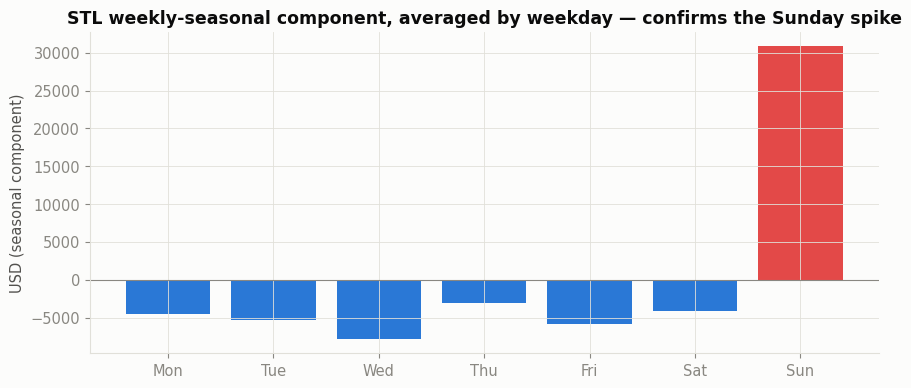

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4))
week_days = np.arange(7)
seasonal_by_dow = stl.seasonal.groupby(stl.seasonal.index.dayofweek).mean()
labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors = [CAT_HEX[7] if l=='Sun' else CAT_HEX[0] for l in labels]
ax.bar(labels, seasonal_by_dow.values, color=colors)
ax.axhline(0, color=INK_MUTE, linewidth=0.8)
ax.set_title('STL weekly-seasonal component, averaged by weekday — confirms the Sunday spike')
ax.set_ylabel('USD (seasonal component)')
plt.tight_layout(); plt.show()



## 11. Event study — quantifying the uplift behind each flag

For each promo/calendar flag, we compare mean `Total_Revenue` on "on" vs. "off" days (Welch's
t-test, since variances differ) — this quantifies exactly how large each hidden factor's
association with revenue is, and how confident we can be that it isn't just noise.


In [ ]:

rows = []
for flag in flag_cols:
    g1, g0 = df.loc[df[flag]==1, 'Total_Revenue'], df.loc[df[flag]==0, 'Total_Revenue']
    t, p = stats.ttest_ind(g1, g0, equal_var=False)
    rows.append((flag, len(g1), g0.mean(), g1.mean(), g1.mean()/g0.mean()-1, t, p))
event_tbl = pd.DataFrame(rows, columns=['flag','n_days_on','mean_off','mean_on','uplift_pct','t_stat','p_value'])
event_tbl = event_tbl.sort_values('uplift_pct', ascending=False).reset_index(drop=True)
event_tbl['uplift_pct'] = (event_tbl['uplift_pct']*100).round(1)
event_tbl


,flag,n_days_on,mean_off,mean_on,uplift_pct,t_stat,p_value
0,BFCM_Promo_Effect,17,"59,875.74","170,906.00",185.40,6.61,0.00
1,UWG_Mailing,76,"56,768.16","116,441.44",105.10,8.12,0.00
2,Offline_Promo,152,"57,762.43","82,025.95",42.00,7.47,0.00
3,Promotion_Discount,572,"49,994.43","68,012.59",36.00,9.32,0.00
4,holiday_list,40,"61,497.86","74,134.47",20.50,1.97,0.06


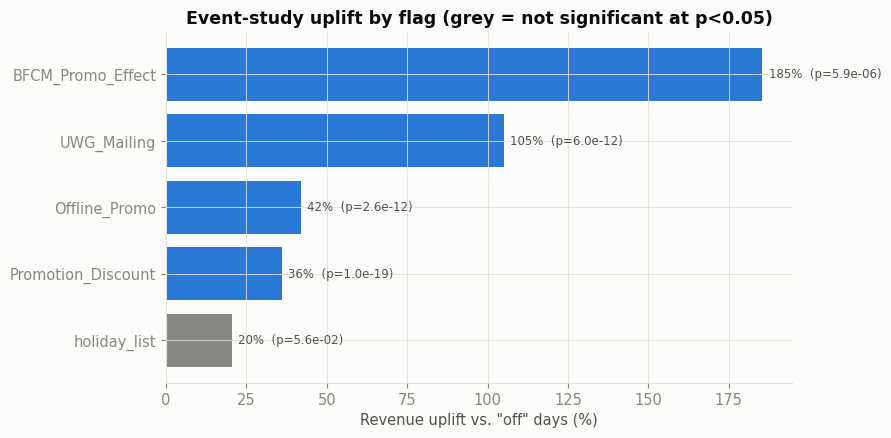

In [ ]:

fig, ax = plt.subplots(figsize=(9, 4.5))
colors = [CAT_HEX[0] if p < 0.05 else INK_MUTE for p in event_tbl['p_value']]
bars = ax.barh(event_tbl['flag'][::-1], event_tbl['uplift_pct'][::-1], color=colors[::-1])
ax.set_xlabel('Revenue uplift vs. "off" days (%)')
ax.set_title('Event-study uplift by flag (grey = not significant at p<0.05)')
for i, (v, p) in enumerate(zip(event_tbl['uplift_pct'][::-1], event_tbl['p_value'][::-1])):
    ax.text(v + 2, i, f'{v:.0f}%  (p={p:.1e})', va='center', fontsize=8.5, color=INK_SOFT)
plt.tight_layout(); plt.show()



**Reading it:** BFCM (+185%) and UWG mailings (+105%) show the largest, most significant
uplifts; `Offline_Promo` (+42%) and `Promotion_Discount` (+36%) are large and significant too;
`holiday_list` (+21%) is directionally positive but only borderline significant (p≈0.06,
n=40 holiday days) — with the small sample and holidays overlapping other flags (e.g. BFCM week
holidays), this one needs the most caution.

Because `UWG_Mailing` co-occurs with `Promotion_Discount` on 70 of its 76 days (92%) and lands
disproportionately on Sundays (part 1 above), a good share of that +105% is **not a pure mailing
effect** — it is Sunday's baseline lift and the promo discount, bundled into the same days. This
is exactly the hidden-factor pattern this notebook set out to find.


In [ ]:

# Isolate the mailing effect from its Sunday/promo overlap: compare mailing vs non-mailing
# *within* Sundays that are already on promo (like-for-like comparison)
sunday_promo = df[(df['dow']=='Sunday') & (df['Promotion_Discount']==1)]
g1 = sunday_promo.loc[sunday_promo['UWG_Mailing']==1, 'Total_Revenue']
g0 = sunday_promo.loc[sunday_promo['UWG_Mailing']==0, 'Total_Revenue']
if len(g1) >= 3 and len(g0) >= 3:
    t, p = stats.ttest_ind(g1, g0, equal_var=False)
    print(f"Within Sunday + promo-discount days only: mailing mean=${g1.mean():,.0f} "
          f"(n={len(g1)}) vs. no-mailing mean=${g0.mean():,.0f} (n={len(g0)}) "
          f"-> like-for-like uplift = {g1.mean()/g0.mean()-1:.1%}, p={p:.3f}")
    print("Compare to the naive +105% uplift above — this like-for-like estimate strips out the")
    print("Sunday and promo-discount overlap and is a cleaner read on the mailing's own contribution.")
else:
    print(f"Only {len(g0)} non-mailing Sunday-promo days available — too few for a reliable "
          f"like-for-like split; treat the naive +105% as an upper bound that mixes in Sunday/promo timing.")


Within Sunday + promo-discount days only: mailing mean=$152,041 (n=29) vs. no-mailing mean=$80,296 (n=63) -> like-for-like uplift = 89.4%, p=0.000
Compare to the naive +105% uplift above — this like-for-like estimate strips out the
Sunday and promo-discount overlap and is a cleaner read on the mailing's own contribution.



## 12. Does the spend↔revenue relationship change over the 2+ years?

A 90-day rolling correlation between `Total_Revenue` and the two largest channels shows whether
the (confounded) relationship is stable, or shifts with the business — e.g. Meta Prospecting was
"scaled up from mid-2024" per the brief, so its correlation with revenue may only firm up later
in the series.


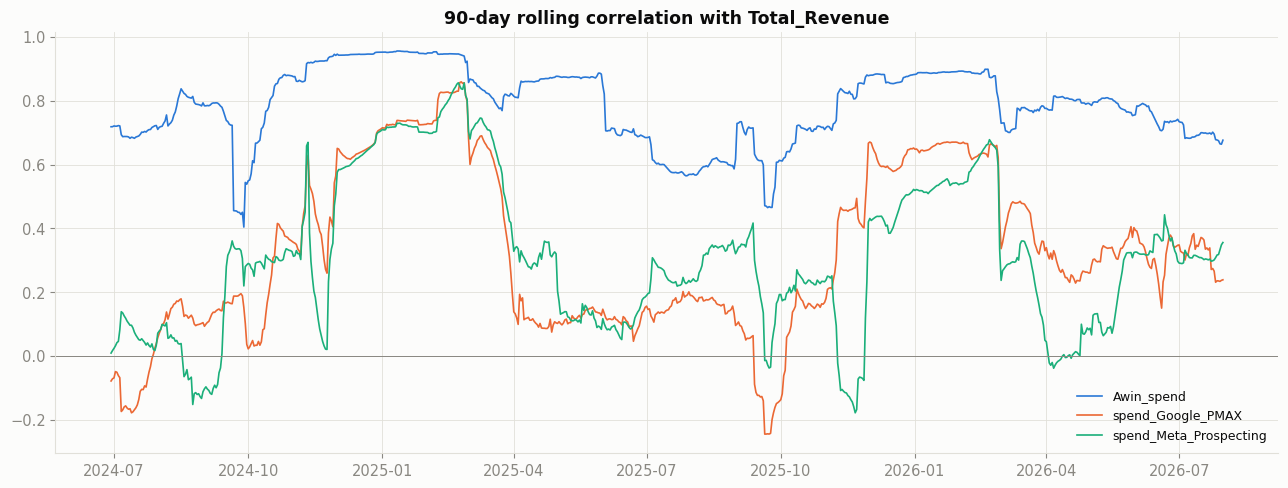

Rolling correlations swing substantially through the series (including brief negative
spells) rather than sitting flat — another sign that the full-sample correlation is an
average over changing promotional/seasonal regimes, not a stable structural relationship.


In [ ]:

roll_window = 90
roll_df = df.set_index('Date')
fig, ax = plt.subplots(figsize=(13, 5))
for i, ch in enumerate(['Awin_spend', 'spend_Google_PMAX', 'spend_Meta_Prospecting']):
    roll_corr = roll_df['Total_Revenue'].rolling(roll_window).corr(roll_df[ch])
    ax.plot(roll_corr.index, roll_corr.values, color=CAT_HEX[i], linewidth=1.2, label=ch)
ax.axhline(0, color=INK_MUTE, linewidth=0.7)
ax.set_title(f'{roll_window}-day rolling correlation with Total_Revenue')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()
print('Rolling correlations swing substantially through the series (including brief negative')
print('spells) rather than sitting flat — another sign that the full-sample correlation is an')
print('average over changing promotional/seasonal regimes, not a stable structural relationship.')



## 13. Synthesis — the hidden factors, and how they move the variables

| Hidden factor | What it actually is | Variables it moves at the same time | Evidence in this notebook |
|---|---|---|---|
| **Day of week (Sunday)** | Not a column in the raw data — derived from `Date` | `Total_Revenue` (+65% vs. weekday avg), the PCA media-intensity factor, and where `UWG_Mailing` lands (31/76 mailings fall on a Sunday) | §4 day-of-week bar chart; §7 PCA-by-weekday chart |
| **BFCM window** | `BFCM_Promo_Effect` flag, ~2% of days | `Total_Revenue` (+185% uplift, largest of any flag), the PCA media-intensity factor (corr 0.57), November monthly spend pattern | §7 PC1-by-month; §11 event study |
| **Site-wide promo discount** | `Promotion_Discount`, live ~67% of days | `Total_Revenue` (+36%), and co-occurs with 92% of `UWG_Mailing` days, diluting the "pure" mailing effect | §11 event study; §11 like-for-like Sunday+promo split |
| **Coordinated media-budget "push"** | Latent factor (PCA PC1, 31% of spend variance) — not a single labelled column | PMAX, Meta ASC/Retargeting/Prospecting, Google Non-Branded and Awin all rise together on the same days | §8 PCA loadings table |
| **Affiliate commission structure** | `Awin_spend` is paid *as a % of the sales it's attributed to* | Mechanically linked to `Total_Revenue` in both directions — the highest raw correlation of any channel (0.76) partly reflects this reverse link, not only a forward media effect | §6 raw correlations; §7 partial correlation (still highest after adjustment, but smaller) |
| **Linear growth trend** | The business grew over the 2+-year window | Slowly inflates both cumulative spend and revenue together, adding a small amount of "correlation for free" | §7 residualization controls included `t` (trend) explicitly |

**What the correlation/confounding work shows, in one line:** most of the raw correlation
between paid media spend and revenue is real but **overstated**, because Northfield's own
playbook (flex media up during promos/BFCM, and disproportionately mail the loyalty file on
Sundays) means spend, mailings and the natural weekly/seasonal demand cycle all move together.
Once day-of-week, the five promo/calendar flags and the growth trend are held constant, spend↔revenue
correlations shrink across the board (most sharply for `spend_Meta_Prospecting`, -55% relative),
and the lag analysis (§9, everything peaks at lag 0) is consistent with same-day reactive
budgeting rather than a delayed causal media effect.



## 14. Key findings

1. **Data is clean**: complete daily coverage (852/852 days), no duplicates or missing values,
   roll-up columns reconcile with their components, and every revenue outlier is explained by a
   known promo/mailing/BFCM event rather than a data error.
2. **Day-of-week is the single strongest, and most overlooked, driver of revenue** — Sunday runs
   ~65% above the weekday average — and it is *not* one of the five labelled flags, yet it
   confounds several of them (most visibly `UWG_Mailing`, which clusters on Sundays).
3. **BFCM (+185%) and UWG mailings (+105% naive / lower on a like-for-like basis) are the
   largest single-day levers** in the dataset; `Promotion_Discount` (+36%) and `Offline_Promo`
   (+42%) are smaller but still highly significant.
4. **Paid media's raw correlation with revenue is real but inflated by shared timing.** A
   coordinated "media push" (one latent PCA factor across PMAX, Meta and Google Non-Branded)
   tracks Sunday and November/BFCM almost as closely as it tracks revenue itself — that calendar
   rhythm, not a proven media lift, is doing much of the apparent work. `spend_Meta_Prospecting`
   is the channel most affected by this (partial correlation ~55% smaller than raw).
5. **`Awin_spend` (affiliate) looks like the top "driver" of revenue by raw correlation (0.76),
   but it is paid on commission** — some of that correlation runs from revenue to spend, not the
   other way round — a genuine attribution risk the team should be aware of, matching the
   business brief's own question about whether "brand-search and affiliate lines are capturing
   demand created elsewhere."
6. **No channel shows a delayed ("adstock") effect** — every spend↔revenue correlation peaks at
   lag 0 and decays with longer lags, consistent with reactive, same-day budget flexing rather
   than a multi-day build-up in response to media.



## 15. Recommendations / suggested next steps for the business

- **Re-run the media/promo analysis with day-of-week and the promo calendar held constant** (as
  done here) rather than on raw correlations, before making any budget-reallocation decision —
  the raw numbers overstate several channels, especially Meta Prospecting.
- **Separate the mailing effect from its Sunday/promo overlap.** Consider testing `UWG_Mailing`
  on non-Sunday, non-promo days (or via a holdout/suppression test) to get a clean read on its
  incremental value, since 92% of mailings already coincide with a live discount.
- **Treat `Awin_spend`'s correlation with skepticism** until it is decomposed into "genuinely
  incremental affiliate-driven sales" vs. "commission paid on sales that would have happened
  anyway" — the brief itself flags this as an open question worth investigating.
- **The lack of any lagged effect** suggests the current media mix behaves as a short-term
  amplifier of demand that's already there (promo days, Sundays, BFCM) rather than a driver of
  future demand — worth validating with a proper incrementality/holdout test on 1–2 channels
  before concluding media has no lasting effect.
- **Holiday flag (`holiday_list`) is the one association that is not statistically convincing**
  here (p≈0.06) — worth more data or a cleaner definition (e.g. splitting "major" vs. "minor"
  holidays) before treating it as a reliable lever.
